In [ ]:
from google.colab import auth
auth.authenticate_user()


In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "my-capstone-2026-498917"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
# BigQuery to Dataframe
query = """
SELECT *
FROM `my-capstone-2026-498917.my_data.earthquakes`
"""

total_earthquakes = client.query(query).to_dataframe()

total_earthquakes.head()

,id,flag_tsunami,year,month,day,hour,minute,second,focal_depth,eq_primary,...,total_missing,total_missing_description,total_injuries,total_injuries_description,total_damage_millions_dollars,total_damage_description,total_houses_destroyed,total_houses_destroyed_description,total_houses_damaged,total_houses_damaged_description
0,6117,Tsu,1854,5,31,12,59,NaN,<NA>,NaN,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
1,2796,None,1906,12,23,17,22,NaN,<NA>,7.6,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
2,3852,None,1947,4,10,15,58,NaN,<NA>,6.4,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
3,6468,Tsu,1986,5,17,16,20,22.2,26,6.4,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
4,339,None,1052,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
query = """
SELECT *
FROM `my-capstone-2026-498917.my_data.total_earthquakes`
"""

total_earthquakes = client.query(query).to_dataframe()

total_earthquakes.head()

,id,flag_tsunami,year,month,day,hour,minute,second,focal_depth,eq_primary,...,total_missing_description,total_injuries,total_injuries_description,total_damage_millions_dollars,total_damage_description,total_houses_destroyed,total_houses_destroyed_description,total_houses_damaged,total_houses_damaged_description,region_name
0,6117,Tsu,1854,5,31,12,59,NaN,<NA>,NaN,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,North America and Hawaii
1,2796,None,1906,12,23,17,22,NaN,<NA>,7.6,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,North America and Hawaii
2,3852,None,1947,4,10,15,58,NaN,<NA>,6.4,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,North America and Hawaii
3,6468,Tsu,1986,5,17,16,20,22.2,26,6.4,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,North America and Hawaii
4,339,None,1052,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Middle East


# All earthquakes

### Cleaning

In [ ]:
total_earthquakes.shape

(6273, 42)

In [ ]:
total_earthquakes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6273 entries, 0 to 6272
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  6273 non-null   Int64  
 1   flag_tsunami                        1869 non-null   object 
 2   year                                6273 non-null   Int64  
 3   month                               5859 non-null   Int64  
 4   day                                 5705 non-null   Int64  
 5   hour                                4221 non-null   Int64  
 6   minute                              4015 non-null   Int64  
 7   second                              2921 non-null   float64
 8   focal_depth                         3306 non-null   Int64  
 9   eq_primary                          4483 non-null   float64
 10  intensity                           2936 non-null   Int64  
 11  country                             6273 no

In [ ]:
total_earthquakes = total_earthquakes.drop_duplicates()

In [ ]:
total_earthquakes.isna().sum()

,0
id,0
flag_tsunami,4404
year,0
month,414
day,568
hour,2052
minute,2258
second,3352
focal_depth,2967
eq_primary,1790


In [ ]:
# Drop unnecessary columns
total_earthquakes = total_earthquakes.drop(columns=["eq_mag_mw", "eq_mag_ms", "eq_mag_mb", "eq_mag_ml", "eq_mag_mfa", "eq_mag_unk"])

KeyError: "['eq_mag_mw', 'eq_mag_ms', 'eq_mag_mb', 'eq_mag_ml', 'eq_mag_mfa', 'eq_mag_unk'] not found in axis"

- 10 = Central, Western and S. Africa
- 15 = Northern Africa
- 20 = Antarctica
- 30 = East Asia
- 40 = Central Asia and Caucasus
- 50 = Kamchatka and Kuril Islands
- 60 = S. and SE. Asia and Indian Ocean
- 70 = Atlantic Ocean
- 80 = Bering Sea
- 90 = Caribbean
- 100 = Central America
- 110 = Eastern Europe
- 120 = Northern and Western Europe
- 130 = Southern Europe
- 140 = Middle East
- 150 = North America and Hawaii
- 160 = South America
- 170 = Central and South Pacific

In [ ]:
# Create region name column from region_code

region_map = {
    10: 'Central, Western and S. Africa',
    15: 'Northern Africa',
    20: 'Antarctica',
    30: 'East Asia',
    40: 'Central Asia and Caucasus',
    50: 'Kamchatka and Kuril Islands',
    60: 'S. and SE. Asia and Indian Ocean',
    70: 'Atlantic Ocean',
    80: 'Bering Sea',
    90: 'Caribbean',
    100: 'Central America',
    110: 'Eastern Europe',
    120: 'Northern and Western Europe',
    130: 'Southern Europe',
    140: 'Middle East',
    150: 'North America and Hawaii',
    160: 'South America',
    170: 'Central and South Pacific'
}

total_earthquakes['region_name'] = (
    total_earthquakes['region_code']
    .map(region_map)
    .fillna('Unknown')
)

In [ ]:
# Target damage columns
target_cols = ['damage_millions_dollars', 'total_damage_millions_dollars']

# 2. Multiply only those columns
total_earthquakes[target_cols] = total_earthquakes[target_cols] * 1000000


### EDA

In [ ]:
total_earthquakes[["focal_depth", "eq_primary", "intensity", "deaths", "missing", "injuries", "damage_millions_dollars", "houses_destroyed", "houses_damaged"]].describe()

,focal_depth,eq_primary,intensity,deaths,missing,injuries,damage_millions_dollars,houses_destroyed,houses_damaged
count,3306.0,4483.000000,2936.0,2088.0,24.0,1296.0,526.000000,812.0,508.0
mean,40.620085,6.455186,8.257834,3803.465996,1957.083333,2138.868056,1229.801504,17160.752463,24868.147638
std,69.742368,1.041706,1.815682,25423.159582,8846.821792,25761.383657,6640.138032,193990.816163,245298.750238
min,0.0,1.600000,2.0,1.0,1.0,1.0,0.013000,1.0,1.0
25%,10.0,5.700000,7.0,3.0,4.75,10.0,4.000000,67.0,91.5
50%,25.0,6.500000,8.0,21.0,25.5,40.0,23.900000,506.0,680.5
75%,39.0,7.300000,10.0,300.0,232.25,200.0,210.000000,3739.5,3528.25
max,675.0,9.500000,12.0,830000.0,43476.0,799000.0,100000.000000,5360000.0,5360000.0


In [ ]:
total_earthquakes[["total_deaths", "total_missing", "total_injuries", "total_damage_millions_dollars", "total_houses_destroyed", "total_houses_damaged"]].describe()

,total_deaths,total_missing,total_injuries,total_damage_millions_dollars,total_houses_destroyed,total_houses_damaged
count,1835.0,27.0,1316.0,494.000000,846.0,451.0
mean,3897.298638,1811.925926,2328.56079,1761.543522,17673.687943,56637.161863
std,27210.895981,8335.536478,26845.750569,11989.201533,191702.725708,989115.744638
min,1.0,1.0,1.0,0.010000,1.0,1.0
25%,3.0,6.5,10.0,4.235000,65.25,100.0
50%,18.0,30.0,40.5,25.635500,503.0,685.0
75%,259.5,264.5,200.0,281.000000,3493.75,3000.0
max,830000.0,43476.0,799000.0,220085.456000,5360000.0,21000000.0


As expected, the totals are higher than the ones caused directly by the earthquakes.

## Most catastrophic earthquakes

In [ ]:
# Most deaths
total_earthquakes[['id', 'flag_tsunami', 'year', 'month', 'day', 'focal_depth', 'eq_primary', 'intensity', 'location_name', 'deaths', 'total_deaths']].sort_values(by= 'total_deaths', ascending=False).head()

,id,flag_tsunami,year,month,day,focal_depth,eq_primary,intensity,location_name,deaths,total_deaths
1716,732,None,1556,1,23,<NA>,8.0,11,CHINA: SHAANXI PROVINCE,830000,830000
1845,8732,Tsu,2010,1,12,13,7.0,<NA>,HAITI: PORT-AU-PRINCE,316000,316000
5285,64,Tsu,115,12,13,<NA>,7.5,11,TURKEY: ANTAKYA (ANTIOCH),260000,260000
258,131,None,525,5,29,<NA>,7.0,9,"TURKEY: ANTAKYA (ANTIOCH), SAMANDAG",250000,250000
2587,4735,None,1976,7,27,23,7.5,11,CHINA: NE: TANGSHAN,242769,242769


Top 5 by deaths:
1. 732: 830,000
2. 8732: 316,000
3. 64: 260,000
4. 131: 250,000
5. 4735: 242,769

In [ ]:
# Most missing
total_earthquakes[['id', 'flag_tsunami', 'year', 'month', 'day', 'focal_depth', 'eq_primary', 'intensity', 'location_name', 'missing', 'total_missing']].sort_values(by= 'total_missing', ascending=False).head()

,id,flag_tsunami,year,month,day,focal_depth,eq_primary,intensity,location_name,missing,total_missing
3223,3227,Tsu,1923,9,1,35,7.9,<NA>,"JAPAN: TOKYO, YOKOHAMA",43476,43476
601,7221,None,1982,3,28,9,3.5,<NA>,MEXICO: CHIAPAS,<NA>,1755
2973,5694,Tsu,2003,5,21,12,6.8,10,"ALGERIA: ALGIERS, BOUMERDES, REGHIA, THENIA",800,800
4370,5512,None,1999,1,25,17,6.2,<NA>,"COLOMBIA: ARMENIA, CALARCA, PEREIRA, CALDAS, ...",700,700
3493,10369,Tsu,2018,9,28,10,7.5,8,INDONESIA: SULAWESI,667,667


Top 5 by missing:
1. 3227: 43,476
2. 7221: 1,755
3. 5694: 800
4. 5512: 700
5. 10369: 667

In [ ]:
# Most injuries
total_earthquakes[['id', 'flag_tsunami', 'year', 'month', 'day', 'focal_depth', 'eq_primary', 'intensity', 'location_name', 'injuries', 'total_injuries']].sort_values(by= 'total_injuries', ascending=False).head()

,id,flag_tsunami,year,month,day,focal_depth,eq_primary,intensity,location_name,injuries,total_injuries
2587,4735,None,1976,7,27,23,7.5,11,CHINA: NE: TANGSHAN,799000,799000
3103,7843,Tsu,2008,5,12,19,7.9,9,CHINA: SICHUAN PROVINCE,374171,374171
1845,8732,Tsu,2010,1,12,13,7.0,<NA>,HAITI: PORT-AU-PRINCE,30000,300000
3716,5589,None,2001,1,26,16,7.7,10,"INDIA: GUJARAT: BHUJ, AHMADABAD, RAJOKOT; PA...",166836,166836
635,6778,None,2005,10,8,26,7.6,8,"PAKISTAN: MUZAFFARABAD, URI, ANANTNAG, BARAMULA",146599,146599


Top 5 by injuries:
1. 4735: 799,000
2. 7843: 374,171
3. 8732: 300,000
4. 5589: 166,836
5. 6778: 146, 599

In [ ]:
# Most total damage
total_earthquakes[['id', 'flag_tsunami', 'year', 'month', 'day', 'focal_depth', 'eq_primary', 'intensity', 'location_name', 'damage_millions_dollars', 'total_damage_millions_dollars']].sort_values(by= 'total_damage_millions_dollars', ascending=False).head()

,id,flag_tsunami,year,month,day,focal_depth,eq_primary,intensity,location_name,damage_millions_dollars,total_damage_millions_dollars
1374,9799,Tsu,2011,3,11,30,9.1,<NA>,JAPAN: HONSHU,4401.709,220085.456
2450,5399,Tsu,1995,1,16,22,6.9,11,"JAPAN: SW HONSHU: KOBE, AWAJI-SHIMA, NISHINO...",100000.000,100000.000
3103,7843,Tsu,2008,5,12,19,7.9,9,CHINA: SICHUAN PROVINCE,86000.000,86000.000
2210,5372,Tsu,1994,1,17,18,6.7,9,CALIFORNIA: NORTHRIDGE,40000.000,40000.000
1254,8872,Tsu,2010,2,27,23,8.8,9,"CHILE: MAULE, CONCEPCION, TALCAHUANO",30000.000,30000.000


Top 5 by damage (in millions USD):
1. 9799: 220,085
2. 5399: 100,000
3. 7843: 86,000
4. 5372: 40,000
5. 8872: 30,000

In [ ]:
# Most houses destroyed
total_earthquakes[['id', 'flag_tsunami', 'year', 'month', 'day', 'focal_depth', 'eq_primary', 'intensity', 'location_name', 'houses_destroyed', 'total_houses_destroyed']].sort_values(by= 'total_houses_destroyed', ascending=False).head()

,id,flag_tsunami,year,month,day,focal_depth,eq_primary,intensity,location_name,houses_destroyed,total_houses_destroyed
3103,7843,Tsu,2008,5,12,19,7.9,9,CHINA: SICHUAN PROVINCE,5360000,5360000
3843,5430,None,1996,2,3,11,6.6,9,CHINA: YUNNAN PROVINCE: LIJIANG,959000,959000
3223,3227,Tsu,1923,9,1,35,7.9,<NA>,"JAPAN: TOKYO, YOKOHAMA",<NA>,695000
4757,5176,None,1988,11,6,18,7.3,10,CHINA: YUNNAN PROVINCE,412000,412000
4366,7881,None,2008,5,25,10,6.0,<NA>,CHINA: SICHUAN PROVINCE,400000,400000


Top 5 by houses destroyed:
1. 7843: 5,360,000
2. 5430: 959,000
3. 3227: 695,000
4. 5176: 412,000
5. 7881: 400,000

In [ ]:
# Most houses damaged
total_earthquakes[['id', 'flag_tsunami', 'year', 'month', 'day', 'focal_depth', 'eq_primary', 'intensity', 'location_name', 'houses_damaged', 'total_houses_damaged']].sort_values(by= 'total_houses_damaged', ascending=False).head()

,id,flag_tsunami,year,month,day,focal_depth,eq_primary,intensity,location_name,houses_damaged,total_houses_damaged
3103,7843,Tsu,2008,5,12,19,7.9,9,CHINA: SICHUAN PROVINCE,5360000,21000000
1254,8872,Tsu,2010,2,27,23,8.8,9,"CHILE: MAULE, CONCEPCION, TALCAHUANO",500000,500000
1374,9799,Tsu,2011,3,11,30,9.1,<NA>,JAPAN: HONSHU,5618,280920
3488,10134,None,2015,4,25,8,7.8,8,NEPAL: KATHMANDU; INDIA; CHINA; BANGLADESH,269107,269107
1845,8732,Tsu,2010,1,12,13,7.0,<NA>,HAITI: PORT-AU-PRINCE,188383,188383


Top 5 by houses damaged:
1. 7843: 21,000,000
2. 8872: 500,000
3. 9799: 280,920
4. 10134: 269,107
5. 8732: 188,383

## Where do the most significant earthquakes occur?

In [ ]:
total_earthquakes['country'].value_counts()

,count
country,
CHINA,609
JAPAN,411
INDONESIA,398
IRAN,383
TURKEY,330
...,...
GABON,1
MONTSERRAT,1
TASMAN SEA,1


There are 157 unique countries. The top 3 countries are all in Asia. There are most likely many countries that only have a few significant earthquakes.

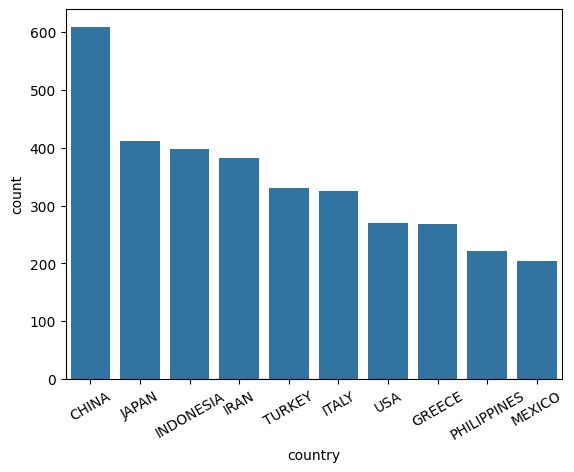

In [ ]:
sns.countplot(x = "country", data = total_earthquakes, order = total_earthquakes.country.value_counts().iloc[:10].index)
plt.xticks(rotation=30)

plt.show()

## How often do significant earthquakes occur?

In [ ]:
total_earthquakes['year'].describe()

,year
count,6273.0
mean,1806.774271
std,375.65617
min,-2150.0
25%,1821.0
50%,1929.0
75%,1989.0
max,2021.0


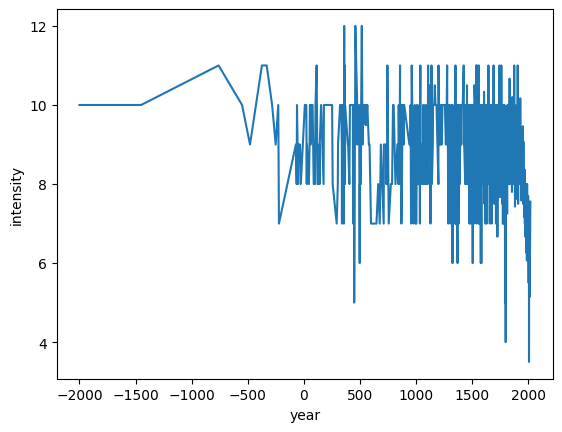

In [ ]:
year_intensity = total_earthquakes[['intensity', 'year']].groupby('year').mean().sort_values(by='year')

sns.lineplot(x = 'year', y = 'intensity', data = year_intensity)
plt.show()

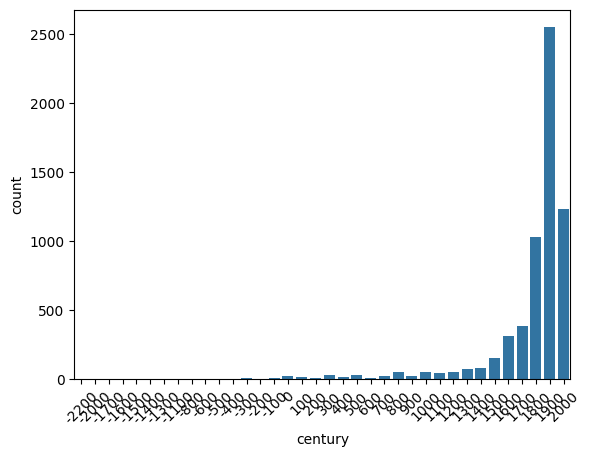

In [ ]:
# Century column
total_earthquakes['century'] = total_earthquakes['year'] - (total_earthquakes['year'] % 100)

sns.countplot(x = 'century', data = total_earthquakes)
plt.xticks(rotation = 45)
plt.show()

The chart above shows that reliable earthquake recording didn't start until around the 1800s.

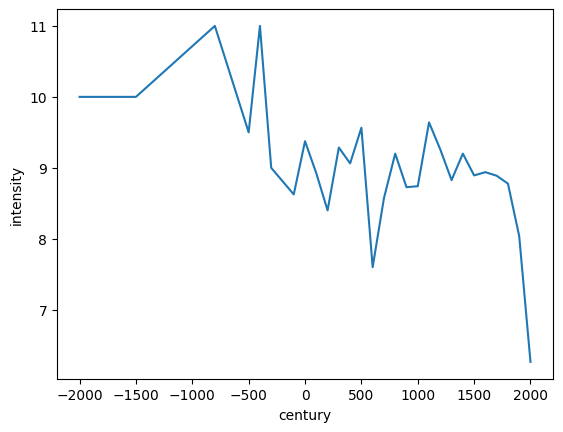

In [ ]:
century_intensity = total_earthquakes[['intensity', 'century']].groupby('century').mean().sort_values(by='century')

sns.lineplot(x = 'century', y = 'intensity', data = century_intensity)
plt.show()

It looks like intentsity goes down over time, but this is most likely because earlier records are estimations.

## Correlations

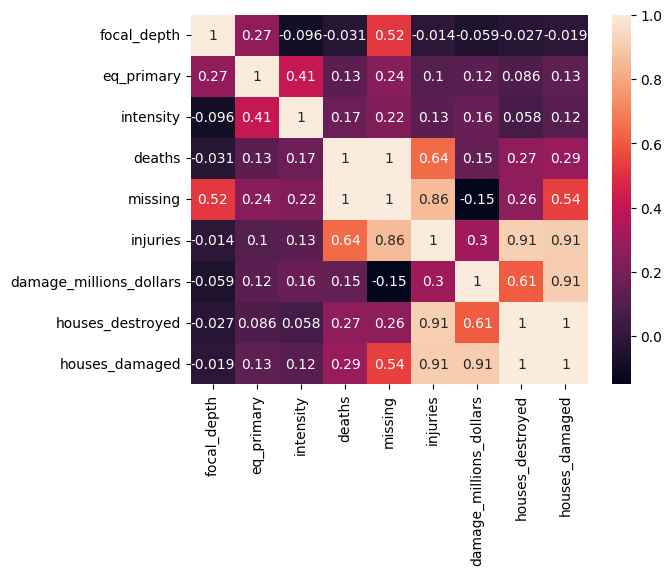

In [ ]:
corr_mat = total_earthquakes[['focal_depth', 'eq_primary', 'intensity','deaths', 'missing', 'injuries', 'damage_millions_dollars', 'houses_destroyed', 'houses_damaged']].corr()

sns.heatmap(corr_mat, annot= True)

plt.show()

High correlations:
- deaths / missing - 1
- houses_destroyed / houses_damaged - 1
- houses_destroyed / injuries - 0.91
- houses_damaged / injuries - 0.91
- houses_damaged / damage_millions_dollars - 0.91
- injuries / missing - 0.86

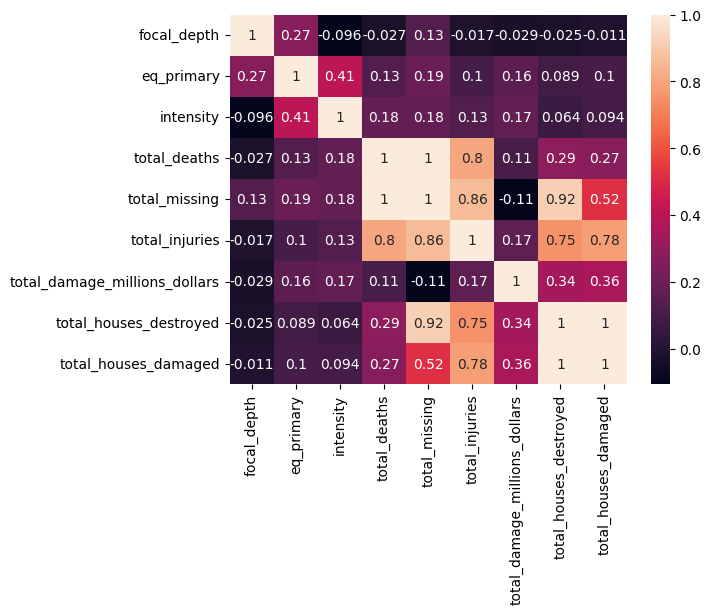

In [ ]:
totals_corr_mat = total_earthquakes[['focal_depth', 'eq_primary', 'intensity','total_deaths', 'total_missing', 'total_injuries', 'total_damage_millions_dollars', 'total_houses_destroyed', 'total_houses_damaged']].corr()

sns.heatmap(totals_corr_mat, annot= True)

plt.show()

High correlations:
- total_deaths / total_missing - 1
- total_houses_destroyed / total_houses_damaged - 1
- total_houses_destroyed / total_missing - 0.92
- total_injuries / total_missing - 0.86
- total_injuries / total_deaths - 0.8
- total_houses_damaged / total_injuries - 0.78
- total_houses_destroyed / total_injuries - 0.75

## Export Data

In [ ]:
# Export data to BigQuery

from pandas_gbq import to_gbq

to_gbq(
    total_earthquakes,
    destination_table='my_data.total_earthquakes',
    project_id='my-capstone-2026-498917',
    if_exists='replace'
)

100%|██████████| 1/1 [00:00<00:00, 8240.28it/s]


# Last 100 years

In [ ]:
# BigQuery to Dataframe
query = """
SELECT *
FROM `my-capstone-2026-498917.my_data.total_earthquakes` t
WHERE t.year >= 1921;
"""

earthquakes_100_years = client.query(query).to_dataframe()

earthquakes_100_years.head()

,id,flag_tsunami,year,month,day,hour,minute,second,focal_depth,eq_primary,...,total_missing,total_missing_description,total_injuries,total_injuries_description,total_damage_millions_dollars,total_damage_description,total_houses_destroyed,total_houses_destroyed_description,total_houses_damaged,total_houses_damaged_description
0,3852,None,1947,4,10,15,58,NaN,<NA>,6.4,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
1,6468,Tsu,1986,5,17,16,20,22.2,26,6.4,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
2,4497,None,1969,10,1,5,5,NaN,43,6.2,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
3,6093,Tsu,1931,3,18,8,2,23.0,33,7.1,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
4,3743,None,1943,5,12,12,25,NaN,<NA>,NaN,...,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
earthquakes_100_years.shape

(3338, 41)

In [ ]:
earthquakes_100_years.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3338 entries, 0 to 3337
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  3338 non-null   Int64  
 1   flag_tsunami                        894 non-null    object 
 2   year                                3338 non-null   Int64  
 3   month                               3336 non-null   Int64  
 4   day                                 3334 non-null   Int64  
 5   hour                                3214 non-null   Int64  
 6   minute                              3196 non-null   Int64  
 7   second                              2758 non-null   float64
 8   focal_depth                         2845 non-null   Int64  
 9   eq_primary                          3124 non-null   float64
 10  intensity                           1359 non-null   Int64  
 11  country                             3338 no